# Optical nerve verification

In [1]:
import sys
import os
sys.path.append('/home/jovyan/projects/cellcount/')
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
#from roifile import ImagejRoi, roiwrite

from read_roi import read_roi_zip
from shapely.geometry import Point, Polygon, MultiPolygon, GeometryCollection
#from shapely.validation import explain_validity, make_valid

from utils import *

/home/jovyan
/home/jovyan/projects/cellcount



Set paths :

In [2]:
path2kdrive = "/home/jovyan/kDrive"
path2data = os.path.join(path2kdrive, 'cellcount/data/onunet/optical_nerve/prediction')
path2plots = os.path.join(path2kdrive, 'cellcount/data/project_Aa_Hr_Fovea/plots')

In [12]:
SPECIES_NAMES = {
    'Cj22': 'Japanese Quail (Cj22)',
    'Ft10': 'Common Kestrel (Ft10)',
    'Mc12': 'Grey Wagtail (Mc12)',
    'Du25': 'House Martin (Du25)',
    'Du26': 'House Martin (Du26)',
    'Aa14': 'Common Swift (Aa14)',
    'Hr11': 'Barn Swallow (Hr11)',
    'Hr21': 'Barn Swallow (Hr21)', 
}
PX_RATIOS = { # microns/pixels
    'Hr11': 1032.15/10422,
    'Hr21': 1120.39/11313,
    'Cj22': 1671.23/16875,
    'Aa14': 1228.76/18684,
    'Du25': 1026.8/10368,
    'Du26': 847.35/8556,
    'Mc12': 1112.37/11232,
    #'Fp23': 2510.86/25353,
    'Ft10': 1949.32/19683
}
COLORS = {
    'Hr11': "#1E72FA",
    'Hr21': "#1E72FA",
    'Aa14': "#E01EFA",
    'Du25': "#0145B3",
    'Du26': "#0145B3",
    'Ft10': "#1ED9FA",
    #'Mm04': "#B87B2B",
    'Mc12': "#975408",
    #'An01': "#E47900",
    'Cj22': "#37FF0F",
    'all':  "#000000"
}
VERIF_PREFIXES = {
    'Hr11': 'ax_cont_predic',
    'Hr21': 'ax_cont_predic',
    'Cj22': 'ax_cont_Cj22',
    'Aa14': 'ax_cont_predic',
    'Du25': 'ax_cont_pred',
    'Du26': 'ax_cont_predic',
    'Mc12': 'ax_cont_predic',
    'Ft10': 'ax_cont_predic'
}

# List of all available species:
all_species = list(SPECIES_NAMES.keys())
all_species

['Cj22', 'Ft10', 'Mc12', 'Du25', 'Du26', 'Aa14', 'Hr11', 'Hr21']

In [13]:
def check_for_verified_tiles(path2directory, prefix):
    '''
    Returns the coordinates of :
    - tiles for which verification exists, i.e., a roiset corresponding to a tile exists
    
    '''
    basepath = Path(path2directory)
    roisets = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.startswith(prefix) and entry.name.endswith('_RoiSet.zip')) # generator
    roiset_names = [entry.name for entry in roisets]
    coords_roisets = []
    for rs_name in roiset_names:
        rs_name_splitted = re.split('_|\.', rs_name)
        i = rs_name_splitted[3]
        j = rs_name_splitted[4]
        #print(i,j)
        coords_roisets.append((int(i),int(j)))

    return coords_roisets


def import_rois_as_polygons(path2directory, i, j, prefix='tile'):
    polygons = []
    path2roifile = os.path.join(path2directory, f"{prefix}_{i}_{j}_RoiSet.zip")
    rois = read_roi_zip(path2roifile)
    # convert rois to shapely.Polygon objects:
    for idx, r in enumerate(rois):
        if min(len(rois[r]['x']), len(rois[r]['y'])) > 3: # avoid an error if number of coords is smaller than 4
            poly = (r, contour2polygon(np.column_stack((rois[r]['x'], rois[r]['y']))))
            polygons.append(poly)

    return polygons

In [14]:
#species = 'Aa14'
thr = 0.5 # micrometers^2
detected_ratios = {}
df_detected_list = []
df_undetected_list = []
for species in all_species:
    print('------------------------------------------')
    print(species)
    # define paths to relevant directories:
    path2verified = os.path.join(path2data, species,'cellmarks_on_tiles')
    #print(path2verified)
    path2predicted = os.path.join(path2data, species,'rois_on_tiles')
    # check which tiles were manually controlled:
    verified_tiles_coords = check_for_verified_tiles(path2verified, prefix=VERIF_PREFIXES[species])
    print("number of verified tiles:", len(verified_tiles_coords))
    print("verified tiles coords:", verified_tiles_coords)
    # import rois as polygons:
    undetected_axons_per_tile = []
    detected_axons_per_tile = []
    for tc in verified_tiles_coords:
        # verification containing the undetected axons:
        undetected_axons_per_tile.append(import_rois_as_polygons(path2verified, tc[0], tc[1], prefix=VERIF_PREFIXES[species]))
        # prediction made by the algorithm:
        detected_axons_per_tile.append(import_rois_as_polygons(path2predicted, tc[0], tc[1], prefix='tile'))
    # concatenate previous lists of rois into a single list:
    undetected_axons = []
    for t in undetected_axons_per_tile:
        undetected_axons += t
    detected_axons = []
    for t in detected_axons_per_tile:
        detected_axons += t
    print("number of detected axons in the verification sample:", len(detected_axons))
    print("number of undetected axons in the verification sample:", len(undetected_axons))

    # the factor 512/850 handles the change of the image size: from axon_contours_predicted,
    # which was manually annotated for verification, to the usual 512x512 tile generated by the algorithm :
    # undetected=manually annotated ; detected=detected by the algorithm
    df_undetected = pd.DataFrame({'area': [p[1].area * (512/850 * PX_RATIOS[species])**2 for p in undetected_axons]})
    df_undetected_list.append(df_undetected)
    df_detected = pd.DataFrame({'area': [p[1].area * PX_RATIOS[species]**2 for p in detected_axons]})
    df_detected = df_detected[df_detected['area'] >= 0.1] # keep only axons with area > 0.1 micometers^2 as smaller are certainly noise
    df_detected_list.append(df_detected)
    
    # compute ratios:
    ratio_small = len(df_detected[df_detected['area'] < thr]) / (len(df_detected[df_detected['area'] < thr]) + len(df_undetected[df_undetected['area'] < thr]))
    ratio_large = len(df_detected[df_detected['area'] >= thr]) / (len(df_detected[df_detected['area'] >= thr]) + len(df_undetected[df_undetected['area'] >= thr]))                                                              
    detected_ratios[species] = [ratio_small, ratio_large]

## Concatenate all species:
df_detected_all = pd.concat(df_detected_list)
df_undetected_all = pd.concat(df_undetected_list)
# compute ratios:
ratio_small_all = len(df_detected_all[df_detected_all['area'] < thr]) / (len(df_detected_all[df_detected_all['area'] < thr]) + len(df_undetected_all[df_undetected_all['area'] < thr]))
ratio_large_all = len(df_detected_all[df_detected_all['area'] >= thr]) / (len(df_detected_all[df_detected_all['area'] >= thr]) + len(df_undetected_all[df_undetected_all['area'] >= thr]))                                                           
detected_ratios['all'] = [ratio_small_all, ratio_large_all]

------------------------------------------
Cj22
number of verified tiles: 15
verified tiles coords: [(5, 18), (14, 19), (9, 22), (19, 6), (4, 14), (14, 10), (20, 6), (5, 15), (13, 16), (15, 6), (14, 20), (14, 4), (15, 2), (8, 23), (16, 4)]
number of detected axons in the verification sample: 20984
number of undetected axons in the verification sample: 1475
------------------------------------------
Ft10
number of verified tiles: 15
verified tiles coords: [(9, 10), (10, 28), (11, 31), (24, 31), (5, 28), (16, 28), (17, 3), (9, 33), (1, 25), (17, 14), (21, 16), (13, 35), (18, 7), (9, 30), (2, 19)]
number of detected axons in the verification sample: 11074
number of undetected axons in the verification sample: 677
------------------------------------------
Mc12
number of verified tiles: 15
verified tiles coords: [(18, 3), (9, 7), (11, 15), (9, 13), (13, 8), (17, 2), (10, 11), (10, 10), (16, 1), (17, 14), (19, 6), (16, 4), (8, 5), (15, 16), (18, 1)]
number of detected axons in the verificat

In [15]:
detected_ratios

{'Cj22': [0.8915582248915582, 0.9498279816513762],
 'Ft10': [0.918918918918919, 0.960209881941408],
 'Mc12': [0.9089420912625332, 0.9455918276704419],
 'Du25': [0.9423585922948731, 0.9844403158383651],
 'Du26': [0.8644520401623584, 0.950661853188929],
 'Aa14': [0.9042709867452136, 0.9618221258134491],
 'Hr11': [0.8649789029535865, 0.9360757049053688],
 'Hr21': [0.7440282121232284, 0.8339563487278427],
 'all': [0.8659173402059074, 0.9290155711150591]}

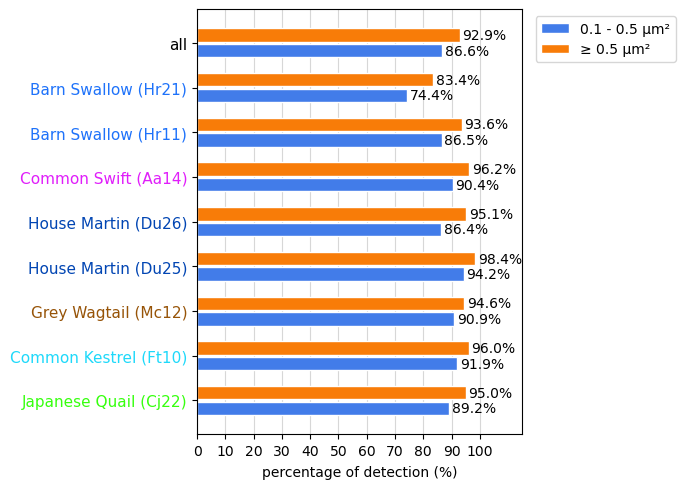

In [62]:
fig, ax = plt.subplots(figsize=(7,5))

num_bars = 2  # Number of bars per group
num_rows = len(all_species) # Number of groups
y_values = np.arange(num_rows)
bar_height = 0.3
offset = 0.05 # space between bars within a group

row_count = 0  # Count of how many sets of bars have been plotted so far
tick_locations = []
species_colors = []  # Store colors for each species in correct order
legend_created = False # Create legend handles for the first iteration only
for species, values in detected_ratios.items():
    if not legend_created:
        leg_lab = ['0.1 - 0.5 μm²', '≥ 0.5 μm²']
        legend_created = True
    else:
        leg_lab = None
    #print(species, values)
    
    bars = ax.barh(
        y=[row_count, row_count + bar_height + offset],
        width=values,
        height=bar_height,
        label = leg_lab,
        edgecolor='white',
        color=["#427CE9", "#F87C08"],
        alpha=1,
        zorder=2
    )

    # Add value annotations at the right of each bar
    for i, (bar, value) in enumerate(zip(bars, values)):
        width = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2
        ax.text(width + 0.01, y_pos, f'{value*100:.1f}%', 
                ha='left', va='center', fontsize=10)

    tick_locations.append(row_count + 0.5 * (bar_height + offset))
    species_colors.append(COLORS[species])
    row_count += 1

ax.set_yticks(tick_locations)
ax.set_yticklabels(list(SPECIES_NAMES.values()) + ["all"], fontsize=11)
# Color the y-axis tick labels
for tick_label, color in zip(ax.get_yticklabels(), species_colors):
    tick_label.set_color(color)

ax.set_xlim(0, 1.15)
x_ticks = np.arange(0, 1.1, 0.1)
ax.set_xticks(x_ticks)
ax.set_xticklabels([int(x * 100) for x in x_ticks])
#ax.grid()
ax.xaxis.grid(alpha=0.5)
ax.set_xlabel("percentage of detection (%)", labelpad=5)

# Position legend outside the plot area
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Adjust layout to accommodate the legend
plt.tight_layout()

fig.savefig(os.path.join(path2plots, 'percentage_of_detection.png'), facecolor='white')

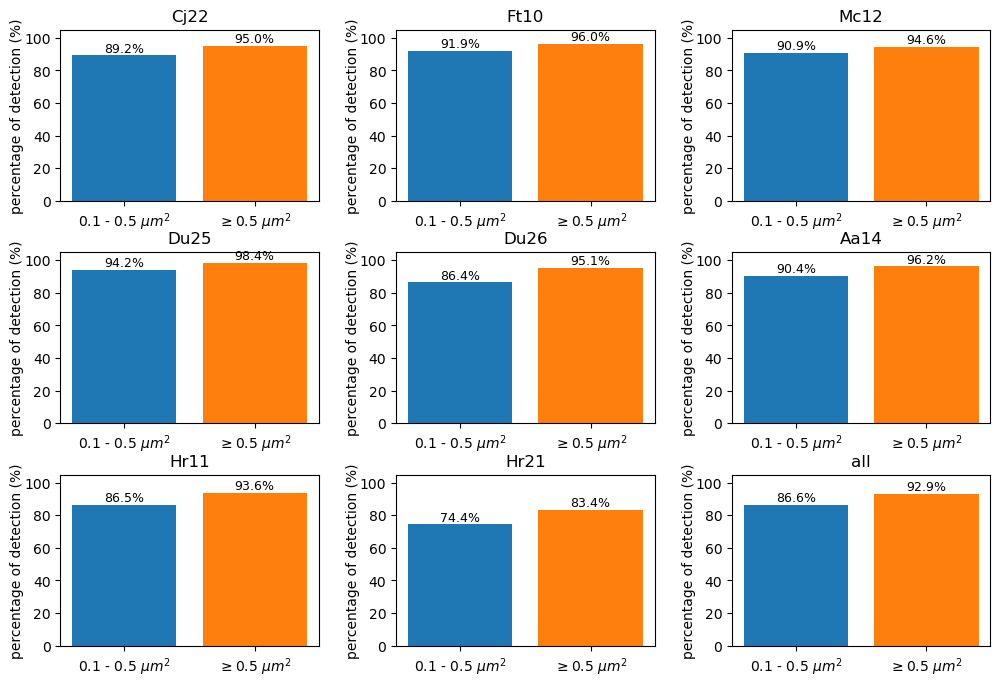

In [42]:
#fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig = plt.figure(figsize=(12, 8))
spec = gridspec.GridSpec(ncols=3, nrows=3, hspace=0.3, wspace=0.3)
#axes = axes.flatten()
for i, species in enumerate(all_species + ['all']):
    ax = fig.add_subplot(spec[i])
    vals = [detected_ratios[species][0] * 100, detected_ratios[species][1] * 100]
    bars = ax.bar(["0.1 - 0.5$~\mu m^2$", "$\geq 0.5~\mu m^2$"], vals, color=['tab:blue','tab:orange'])
    ax.set_ylim(0, 105)
    ax.set_ylabel("percentage of detection (%)", labelpad=0)
    ax.set_title(species)
    # annotate with actual percent values above bars:
    for b, actual in zip(bars, vals):
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.3, f"{actual:.1f}%", ha='center', va='bottom', fontsize=9)

#fig.savefig(os.path.join(path2plots, 'percentage_of_detection.png'), facecolor='white')